# Detecting COVID-19 with Chest X Ray using PyTorch

Image classification of Chest X Rays in one of three classes: Normal, Viral Pneumonia, COVID-19

Notebook created for the guided project [Detecting COVID-19 with Chest X Ray using PyTorch](https://www.coursera.org/projects/covid-19-detection-x-ray) on Coursera

Dataset from [COVID-19 Radiography Dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database) on Kaggle

## Data Kurulumu ve Kütüphanelerin Indirilmesi

In [2]:
!pip install -q kagglehub


In [3]:
import kagglehub

# COVID-19 Radiography Database download
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Veri yolu:", path)


100%|██████████| 778M/778M [00:15<00:00, 52.6MB/s]

Extracting files...


Veri yolu: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5


In [4]:
import os

# Dosyaları listele
os.listdir(path)


['COVID-19_Radiography_Dataset']

In [5]:
!pip install torch torchvision numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [6]:
data_path = os.path.join(path, "COVID-19_Radiography_Dataset")
print(os.listdir(data_path))
# Datanin icerigini görüntüle


['Lung_Opacity', 'README.md.txt', 'Normal', 'COVID.metadata.xlsx', 'Lung_Opacity.metadata.xlsx', 'COVID', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'Normal.metadata.xlsx']


In [7]:
# istedigimiz 3 class'i ayir
import os

data_path = os.path.join(path, "COVID-19_Radiography_Dataset")

# ImageFolder için alt dizin (sadece klasörleri filtrele)
class_dirs = ['COVID', 'Normal', 'Viral Pneumonia']
data_subdir = os.path.join(data_path, 'imagefolder_ready')

os.makedirs(data_subdir, exist_ok=True)

for class_name in class_dirs:
    os.system(f'cp -r "{os.path.join(data_path, class_name)}" "{data_subdir}/"')


# Importing Libraries

In [8]:
# Temel kütüphaneler
import os
import shutil
import random
import torch
import torchvision
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Görüntü işleme ve görselleştirme
from PIL import Image
from matplotlib import pyplot as plt

# Seed (rastgeleliği kontrol altına almak için)
torch.manual_seed(0)

# Versiyon kontrolü
print('Using PyTorch version', torch.__version__)


Using PyTorch version 2.6.0+cu124


# Preparing Training and Test Sets

In [9]:
import os
import shutil
import random

root_dir = os.path.join(path, "COVID-19_Radiography_Dataset")

# Gerçekten var olanlar üzerinden kontrol yap
rename_map = {
    'Normal': 'normal',
    'COVID': 'covid',
    'Viral Pneumonia': 'viral'
}

# 1. Yeniden adlandır
for src_name, dst_name in rename_map.items():
    src = os.path.join(root_dir, src_name)
    dst = os.path.join(root_dir, dst_name)
    if os.path.exists(src) and not os.path.exists(dst):
        os.rename(src, dst)
        print(f"✓ Renamed: {src_name} → {dst_name}")

# 2. test klasörlerini oluştur
test_dir = os.path.join(root_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

class_names = ['normal', 'viral', 'covid']
for class_name in class_names:
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

# 3. Her sınıftan 30 rastgele görseli test'e taşı

for class_name in class_names:
    class_path = os.path.join(root_dir, class_name, "images")  # ← Bunu böyle olmalı!
    images = [x for x in os.listdir(class_path) if x.lower().endswith(('png', 'jpg', 'jpeg'))]
    selected = random.sample(images, 30)

    for img in selected:
        src = os.path.join(class_path, img)
        dst = os.path.join(root_dir, 'test', class_name, img)
        shutil.move(src, dst)

✓ Renamed: Normal → normal
✓ Renamed: COVID → covid
✓ Renamed: Viral Pneumonia → viral


## Creating Custom Dataset

In [10]:
class ChestXRayDataset(torch.utils.data.Dataset):
    def __init__(self, image_dirs, transform):
        def get_images(class_name):
            images = [x for x in os.listdir(image_dirs[class_name]) if x.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f'Found {len(images)} {class_name} examples')
            return images

        self.images = {}
        self.class_names = ['normal', 'viral', 'covid']

        for class_name in self.class_names:
            self.images[class_name] = get_images(class_name)

        self.image_dirs = image_dirs
        self.transform = transform

    def __len__(self):
        return sum([len(self.images[class_name]) for class_name in self.class_names])

    def __getitem__(self, index):
        class_name = random.choice(self.class_names)
        index = index % len(self.images[class_name])
        image_name = self.images[class_name][index]
        image_path = os.path.join(self.image_dirs[class_name], image_name)
        image = Image.open(image_path).convert('RGB')
        return self.transform(image), self.class_names.index(class_name)


## Image Transfortions

In [11]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Augmentasion Beispiel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## Prepare DataLoader

In [12]:
print(os.listdir(os.path.join(root_dir, "normal", "images"))[:5])


['Normal-7559.png', 'Normal-405.png', 'Normal-2193.png', 'Normal-6204.png', 'Normal-4227.png']


In [13]:
root_dir = os.path.join(path, "COVID-19_Radiography_Dataset")


In [14]:
train_dirs = {
    'normal': os.path.join(root_dir, 'normal', 'images'),
    'viral': os.path.join(root_dir, 'viral', 'images'),
    'covid': os.path.join(root_dir, 'covid', 'images')
}


train_dataset = ChestXRayDataset(train_dirs, train_transform)

Found 10162 normal examples
Found 1315 viral examples
Found 3586 covid examples


In [15]:
test_dirs = {
    'normal': os.path.join(root_dir, 'test', 'normal'),
    'viral': os.path.join(root_dir, 'test', 'viral'),
    'covid': os.path.join(root_dir, 'test', 'covid')
}

test_dataset = ChestXRayDataset(test_dirs, test_transform)

Found 30 normal examples
Found 30 viral examples
Found 30 covid examples


In [17]:
from torch.utils.data import DataLoader

# Batch size
batch_size = 6

# Eğitim verisi DataLoader
dl_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Test verisi DataLoader
dl_test = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

# Kaç batch olduğunu yazdıralım
print(f"🔹 Number of training batches: {len(dl_train)}")
print(f"🔹 Number of test batches: {len(dl_test)}")


🔹 Number of training batches: 2511
🔹 Number of test batches: 15


## Data Visualization

In [18]:
# Class isimlerini al
class_names = train_dataset.class_names

# Görselleri çizdirme fonksiyonu
def show_images(images, labels, preds):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(12, 4))
    for i, image in enumerate(images):
        plt.subplot(1, len(images), i + 1, xticks=[], yticks=[])

        # Tensor'u NumPy array'e çevir ve kanal sırasını düzelt (CHW → HWC)
        image = image.cpu().numpy().transpose((1, 2, 0))

        # Denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = image * std + mean
        image = np.clip(image, 0., 1.)

        # Görseli göster
        plt.imshow(image)

        # Tahmin doğruysa yeşil, yanlışsa kırmızı yaz
        col = 'green' if preds[i] == labels[i] else 'red'
        plt.xlabel(f' {class_names[labels[i]]}', fontsize=10)
        plt.ylabel(f' {class_names[preds[i]]}', color=col, fontsize=10)

    plt.tight_layout()
    plt.show()


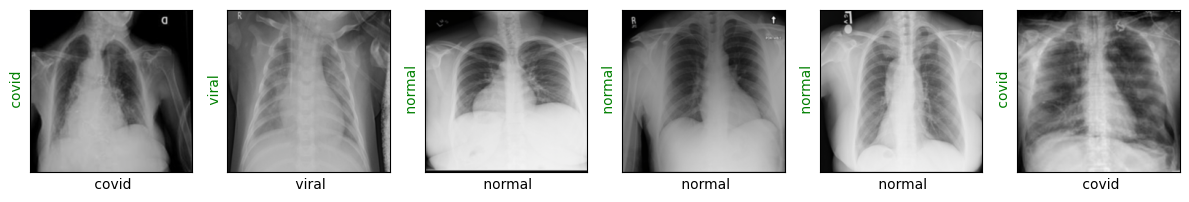

In [19]:
images, labels = next(iter(dl_train))
show_images(images, labels, labels)


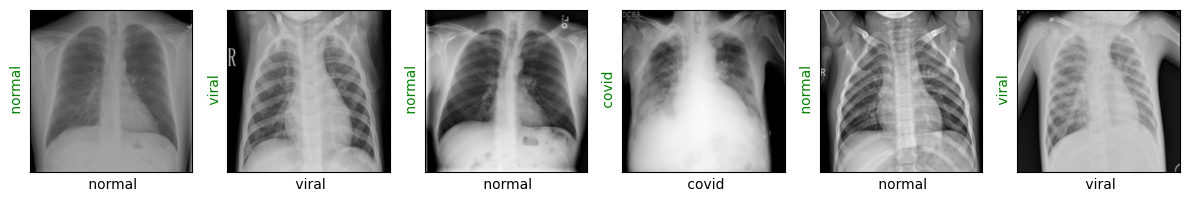

In [20]:
images, labels = next(iter(dl_test))
show_images(images, labels, labels)


## Creating the Model

In [21]:
resnet18 = torchvision.models.resnet18(pretrained=True)

print(resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 156MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
resnet18.fc = torch.nn.Linear(in_features=512, out_features=3)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=3e-5)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18.to(device)

def show_preds():
    resnet18.eval()
    images, labels = next(iter(dl_test))

    # ✅ Verileri aynı cihaza taşı (GPU/CPU)
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = resnet18(images)
        _, preds = torch.max(outputs, 1)

    # 👁️ Görselleştirme için CPU’ya geri al
    show_images(images.cpu(), labels.cpu(), preds.cpu())


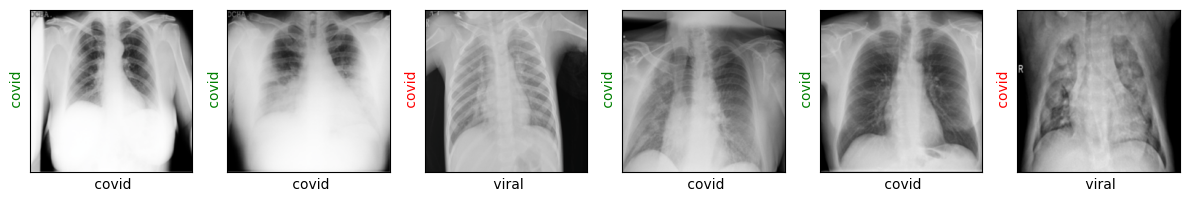

In [25]:
show_preds()

## Training the Model

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18.to(device)

def train(epochs):
    train_loss_list = []
    val_loss_list = []
    accuracy_list = []

    print('Starting training..')
    for e in range(epochs):
        print('='*20)
        print(f'Starting epoch {e + 1}/{epochs}')
        print('='*20)

        train_loss = 0.
        val_loss = 0.

        train_step = -1

        resnet18.train()  # Eğitim moduna al

        for train_step, (images, labels) in enumerate(dl_train):
            # Verileri GPU'ya al (isteğe bağlı, Colab için)
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = resnet18(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Her 20 adımda validasyon yap
            if train_step % 100 == 0:
                print('Evaluating at step', train_step)

                accuracy = 0
                resnet18.eval()  # Değerlendirme moduna geç

                with torch.no_grad():  # Gradient hesabını kapat
                    for val_step, (val_images, val_labels) in enumerate(dl_test):
                        val_images = val_images.to(device)
                        val_labels = val_labels.to(device)

                        val_outputs = resnet18(val_images)
                        val_loss += loss_fn(val_outputs, val_labels).item()
                        _, preds = torch.max(val_outputs, 1)
                        accuracy += (preds == val_labels).sum().item()

                val_loss /= (val_step + 1)
                accuracy /= len(test_dataset)

                print(f'Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}')


                train_loss_list.append(train_loss / (train_step + 1))
                val_loss_list.append(val_loss)
                accuracy_list.append(accuracy)

                resnet18.train()  # Tekrar eğitim moduna dön

                # Başarı kriteri: %95 doğruluk
                #if accuracy >= 0.95:
                    #print('✅ Performans eşiği aşıldı. Eğitim durduruluyor.')
                    #return train_loss_list, val_loss_list, accuracy_list

                    #if train_step >= 0:
                        #train_loss /= (train_step + 1)  # 🔐 Güvenli böl
                    #else:
                        #train_loss = 0  # İlk adımdan önce çıkarsa hata olmasın

                    #return train_loss_list, val_loss_list, accuracy_list
        train_loss /= (train_step + 1)
        print(f'Training Loss: {train_loss:.4f}')

    print('✅ Eğitim tamamlandı.')
    return train_loss_list, val_loss_list, accuracy_list


In [29]:
print("batch anzahl:", len(dl_train))


batch anzahl: 2511


In [30]:
%%time

train_loss_list, val_loss_list, accuracy_list = train(epochs=1)


Starting training..
Starting epoch 1/1
Evaluating at step 0
Validation Loss: 1.3721, Accuracy: 0.2778
Evaluating at step 100
Validation Loss: 0.3880, Accuracy: 0.8889
Evaluating at step 200
Validation Loss: 0.2617, Accuracy: 0.9000
Evaluating at step 300
Validation Loss: 0.1590, Accuracy: 0.9333
Evaluating at step 400
Validation Loss: 0.1113, Accuracy: 0.9667
Evaluating at step 500
Validation Loss: 0.2137, Accuracy: 0.9000
Evaluating at step 600
Validation Loss: 0.1505, Accuracy: 0.9111
Evaluating at step 700
Validation Loss: 0.0749, Accuracy: 0.9778
Evaluating at step 800
Validation Loss: 0.0658, Accuracy: 0.9889
Evaluating at step 900
Validation Loss: 0.1570, Accuracy: 0.9556
Evaluating at step 1000
Validation Loss: 0.1618, Accuracy: 0.9667
Evaluating at step 1100
Validation Loss: 0.0748, Accuracy: 0.9889
Evaluating at step 1200
Validation Loss: 0.0569, Accuracy: 1.0000
Evaluating at step 1300
Validation Loss: 0.0826, Accuracy: 0.9667
Evaluating at step 1400
Validation Loss: 0.1286, 

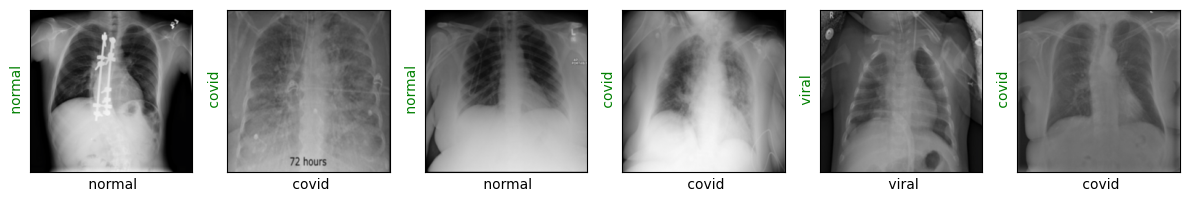

In [31]:
show_preds()

## Save and Reload

In [32]:
# Eğitim tamamlandıktan sonra modeli kaydet
torch.save(resnet18.state_dict(), 'resnet18_covid.pth')
print("✅ Das model wurde erfolgreich gespeichert.")

✅ Das model wurde erfolgreich gespeichert.


In [33]:
# Yeni bir model tanımlayıp eğitilmiş ağırlıkları yükle
loaded_model = torchvision.models.resnet18(pretrained=False)
loaded_model.fc = torch.nn.Linear(in_features=512, out_features=3)
loaded_model.load_state_dict(torch.load('resnet18_covid.pth'))
loaded_model.eval()  # Inference moduna al
print("📥 Das Model wurde erfolgreich hochgeladet.")


📥 Das Model wurde erfolgreich hochgeladet.


## Visualisierung

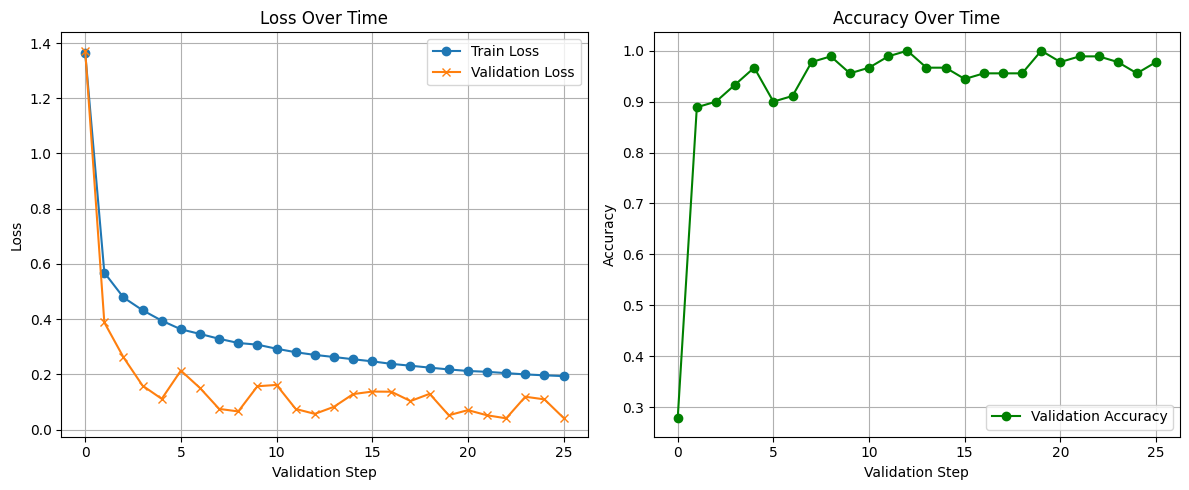

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Kayıp (Loss)
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss', marker='o')
plt.plot(val_loss_list, label='Validation Loss', marker='x')
plt.xlabel('Validation Step')
plt.ylabel('Loss')
plt.title('Loss Over Time')
plt.legend()
plt.grid(True)

# 2. Doğruluk (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(accuracy_list, label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Validation Step')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#### Die Trainingsverluste (Loss) sinken kontinuierlich, während die Validierungsverluste etwas schwanken, aber insgesamt niedrig bleiben. Die Validierungsgenauigkeit (Accuracy) ist bereits früh sehr hoch (90–100 %), was darauf hinweist, dass das Modell die Daten gut gelernt hat. Es könnte jedoch notwendig sein, die Datenverteilung nochmals zu prüfen oder größere Datensätze zu verwenden, um Überanpassung (Overfitting) auszuschließen.